In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df = pd.read_csv("Social_Network_Ads.csv")
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [3]:
X = df.iloc[:,:-1].values
y = df.iloc[:,-1].values

In [4]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=2,stratify=y)

In [5]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test)

In [6]:
from sklearn.naive_bayes import GaussianNB
clsf = GaussianNB()
clsf.fit(X_train_sc,y_train)

GaussianNB()

In [10]:
print(clsf.predict(sc.transform([[30,87000]])))

[0]


In [11]:
y_pred = clsf.predict(X_test_sc)

In [12]:
from sklearn.metrics import confusion_matrix,accuracy_score
cm = confusion_matrix(y_test,y_pred)
print(cm)

[[58  6]
 [ 5 31]]


<Axes: >

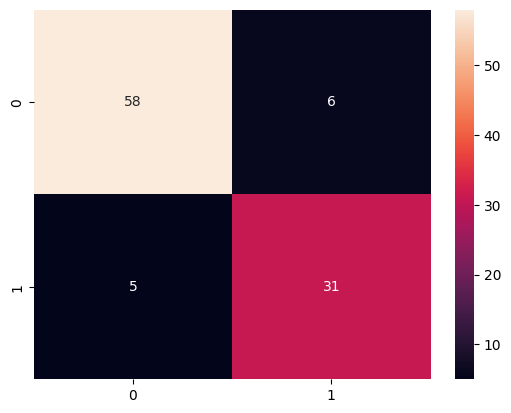

In [13]:
import seaborn as sns
sns.heatmap(cm,annot=True)

<ipython-input-14-21f00b06bfd5>:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set==j,0],X_set[y_set==j,1],c = ListedColormap(("black","white"))(i),label=j)


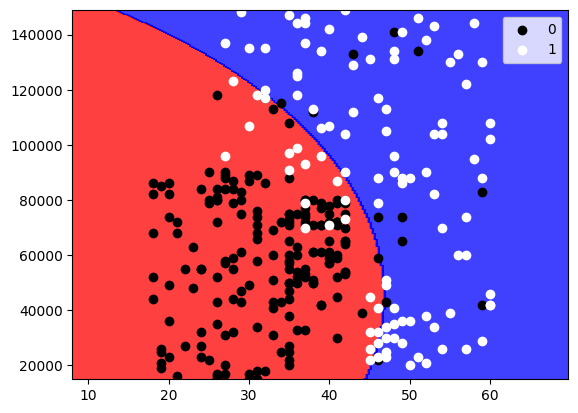

In [14]:
from matplotlib.colors import ListedColormap
X_set,y_set = X_train,y_train
X1,X2 = np.meshgrid(np.arange(start=X_set[:,0].min()-10,stop=X_set[:,0].max()+10,step=0.25),
                    np.arange(start=X_set[:,1].min()-10,stop=X_set[:,1].max()+10,step=0.25))
plt.contourf(X1,X2,clsf.predict(sc.transform(np.array([X1.ravel(),X2.ravel()]).T)).reshape(X1.shape),
             alpha=0.75,cmap=ListedColormap(('red','blue')))
plt.xlim(X1.min(),X1.max())
plt.ylim(X2.min(),X2.max())
for i,j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set==j,0],X_set[y_set==j,1],c = ListedColormap(("black","white"))(i),label=j)
plt.legend()

<ipython-input-15-4d4fd327e207>:9: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set==j,0],X_set[y_set==j,1],c = ListedColormap(("black","white"))(i),label=j)


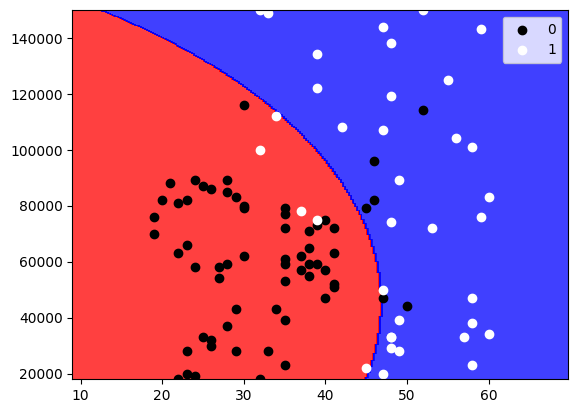

In [15]:
X_set,y_set = X_test,y_test
X1,X2 = np.meshgrid(np.arange(start=X_set[:,0].min()-10,stop=X_set[:,0].max()+10,step=0.25),
                    np.arange(start=X_set[:,1].min()-10,stop=X_set[:,1].max()+10,step=0.25))
plt.contourf(X1,X2,clsf.predict(sc.transform(np.array([X1.ravel(),X2.ravel()]).T)).reshape(X1.shape),
             alpha=0.75,cmap=ListedColormap(('red','blue')))
plt.xlim(X1.min(),X1.max())
plt.ylim(X2.min(),X2.max())
for i,j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set==j,0],X_set[y_set==j,1],c = ListedColormap(("black","white"))(i),label=j)
plt.legend()